**Note:** The data has been pre-cleaned in a separate notebook. This notebook focuses exclusively on the analysis and insights.

# E-commerce Funnel & User Behavior Analysis

Imagine an e-commerce platform where users browse products, add items to their cart, and ideally complete a purchase. 
Understanding how users move through this journey is key for optimizing the shopping experience.

This notebook explores user behavior on a simulated e-commerce platform, capturing interactions from **500 unique users** across multiple sessions over 10 days. 
Users come from **Italy, Germany, France, and Spain**, access the site via **desktop or mobile**, and are categorized as **New or Returning**.

The analysis focuses on the main stages of the purchase funnel: **page views → product views → add to cart → checkout → purchase**. 
By tracking **step conversions** and **drop-offs**, we can identify friction points, understand user engagement, and see where the platform may lose potential buyers.

This project is a **learning exercise in Pandas** for sequential funnel analysis, aggregation, and visualization, and serves as a practical case for understanding user behavior in e-commerce.

## Objective
- To understand how users progress through the purchase funnel.
- Indentify key drop-off points.
- Explore behavioral differences across countries, devices, and user types.
- Propose areas for potential improvements in user experience and conversion, such as checkout flow, cart abandonment, and onboarding for new users.

## 🧹 Data Preparation

The dataset was pre-cleaned in a separate notebook.  
This analysis uses a structured dataset containing the following columns:

- `user_id` – unique identifier for each user  
- `session_id` – unique identifier for each session  
- `event` – type of user interaction (page_view, product_view, add_to_cart, checkout, purchase)  
- `page` – the page visited  
- `category` – product or content category  
- `timestamp` – date and time of the event  
- `device` – type of device used (desktop and mobile)  
- `country` – user's country  
- `user_type` – user segment or classification (new or returning)



## 🧭 Exploratory Data Analysis & Data Preparation

Before starting the analysis, an exploratory data analysis (EDA) was performed to better understand the dataset and ensure its reliability. [View EDA_and_cleaning](EDA_and_cleaning.ipynb)

Key steps included:
- Examining the dataset structure and dimensions
- Validating and converting data types
- Preparing variables for efficient analysis

In particular:
- The `timestamp` field was converted into a datetime format to enable time-based analysis
- Relevant columns were cast as categorical variables to improve performance and consistency

This preparation step is critical to ensure that all subsequent analyses are accurate and meaningful.

In [51]:
# Import libreries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

In [52]:
# Load clean dataset

clean_path = os.path.join("..", "data", "clean", "df_clean.csv")
df_clean = pd.read_csv(clean_path)

print("Database shape:", df_clean.shape)
df_clean.head()

Database shape: (2944, 9)


,user_id,session_id,event,page,category,timestamp,device,country,user_type
0,103,s103_2,product_view,product_page,sports,2026-03-03 06:02:00,mobile,it,returning
1,221,s221_1,product_view,product_page,accessories,2026-03-09 21:15:19,desktop,it,new
2,291,s291_2,page_view,homepage,unknown,2026-03-05 05:02:52,unknown,es,new
3,278,s278_1,page_view,homepage,unknown,2026-03-03 14:39:06,desktop,es,new
4,492,s492_4,page_view,homepage,unknown,2026-03-07 20:33:17,desktop,fr,new


In [53]:
# data types
df_clean.dtypes

user_id       int64
session_id      str
event           str
page            str
category        str
timestamp       str
device          str
country         str
user_type       str
dtype: object

In [54]:
# convert timestamp to datetime
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

In [55]:
# verify data type 
df_clean.dtypes

user_id                int64
session_id               str
event                    str
page                     str
category                 str
timestamp     datetime64[us]
device                   str
country                  str
user_type                str
dtype: object

In [56]:
# convert 'event', 'page', 'category', 'device', 'country', 'user_type' to category
cat_cols = ['event', 'page', 'category', 'device', 'country', 'user_type']

for col in cat_cols:
    df_clean[col] = df_clean[col].astype('category')

print(df_clean.dtypes)

user_id                int64
session_id               str
event               category
page                category
category            category
timestamp     datetime64[us]
device              category
country             category
user_type           category
dtype: object


## 📊 Event Distribution

The first step was to understand overall user activity.

              Count  Percentage
event                          
page_view      1515       51.46
product_view   1082       36.75
add_to_cart     281        9.54
checkout         58        1.97
purchase          8        0.27


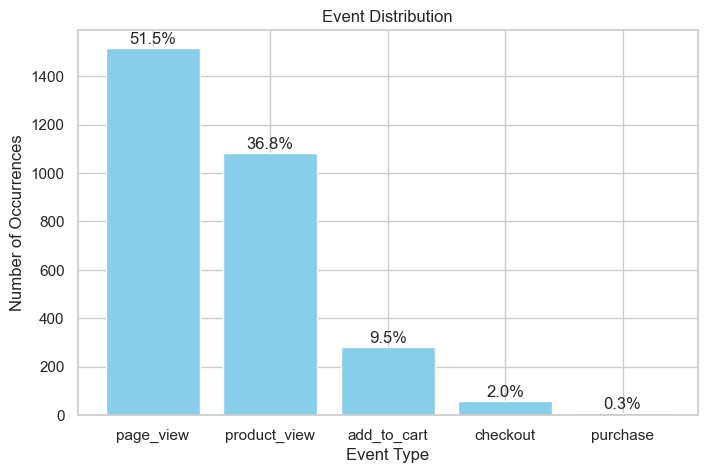

In [ ]:
import matplotlib.pyplot as plt

# Count events
event_counts = df_clean['event'].value_counts()
event_percent = df_clean['event'].value_counts(normalize=True) * 100  # % de cada evento

# Show table with count and percentage
event_distribution = pd.DataFrame({
    'Count': event_counts,
    'Percentage': event_percent.round(2)
})
print(event_distribution)

# Visualization with percentage labels
plt.figure(figsize=(8,5))
bars = plt.bar(event_counts.index, event_counts.values, color='skyblue')

plt.title("Event Distribution")
plt.ylabel("Number of Occurrences")
plt.xlabel("Event Type")

# Add percentage labels on top of each bar
for bar, pct in zip(bars, event_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'{pct:.1f}%', ha='center', va='bottom')

plt.show()

### Insight:

- Most users interact with early-stage events (page views, product views)

- A significant drop occurs before purchase-related actions

👉 **This suggests potential friction in the lower funnel stages.**

## Open Funnel Analysis

Users are counted for each step independently without enforcing the sequence of steps  

In [58]:
# Check events
print(df_clean['event'].unique())

# Define sequence of events
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout', 'purchase']

['product_view', 'page_view', 'add_to_cart', 'checkout', 'purchase']
Categories (5, str): ['add_to_cart', 'checkout', 'page_view', 'product_view', 'purchase']


In [59]:
# Pivot table by user
funnel = df_clean.pivot_table(
    index='user_id',
    columns='event',
    aggfunc='size',
    fill_value=0
)

# Convert to boolean (1 = passed the step. 0 = did not pass)
funnel_bool= funnel[funnel_steps].astype(bool)

funnel_bool.head()

event,page_view,product_view,add_to_cart,checkout,purchase
user_id,,,,,
1,True,True,True,False,False
2,True,True,False,False,False
3,True,True,False,False,False
4,True,True,True,False,False
5,True,True,True,False,False


In [60]:
funnel_bool.tail()

event,page_view,product_view,add_to_cart,checkout,purchase
user_id,,,,,
496,True,True,True,False,False
497,True,True,True,False,False
498,True,True,True,False,False
499,True,True,True,True,False
500,True,True,True,False,False


In [61]:
# Count users by step
# In this case it counts users did not necesarily passed the previous steps
funnel_counts = funnel_bool.sum().reset_index()
funnel_counts.columns = ['step', 'users']
funnel_counts

,step,users
0,page_view,500
1,product_view,460
2,add_to_cart,214
3,checkout,54
4,purchase,8


In [62]:
# Add column conversion_rate (% respect to page_view) 
funnel_counts['conversion_rate'] = (
    funnel_counts['users'] / funnel_counts['users'].iloc[0] * 100
).round(1)

# Add column step_conversion 
funnel_counts['step_conversion'] = (
    funnel_counts['users'] / funnel_counts['users'].shift(1) * 100
).round(1)

# For the first step, there is no previous step, then fill with 100
funnel_counts.loc[0, 'step_conversion'] = 100

funnel_counts

,step,users,conversion_rate,step_conversion
0,page_view,500,100.0,100.0
1,product_view,460,92.0,92.0
2,add_to_cart,214,42.8,46.5
3,checkout,54,10.8,25.2
4,purchase,8,1.6,14.8


### Drop-off

In [63]:
# Absolute drop-off
funnel_counts['drop_abs'] = funnel_counts['users'].shift(1) - funnel_counts['users']
funnel_counts.loc[0, 'drop_abs'] = 0

# Conversion rate
funnel_counts['conversion_rate'] = (
    funnel_counts['users'] / funnel_counts['users'].shift(1)
)

# Drop percent
funnel_counts['drop_percent'] = (
    (1 - funnel_counts['conversion_rate']) * 100
).round(1)

funnel_counts.loc[0, ['conversion_rate', 'drop_percent']] = 0

funnel_counts

,step,users,conversion_rate,step_conversion,drop_abs,drop_percent
0,page_view,500,0.000000,100.0,0.0,0.0
1,product_view,460,0.920000,92.0,40.0,8.0
2,add_to_cart,214,0.465217,46.5,246.0,53.5
3,checkout,54,0.252336,25.2,160.0,74.8
4,purchase,8,0.148148,14.8,46.0,85.2


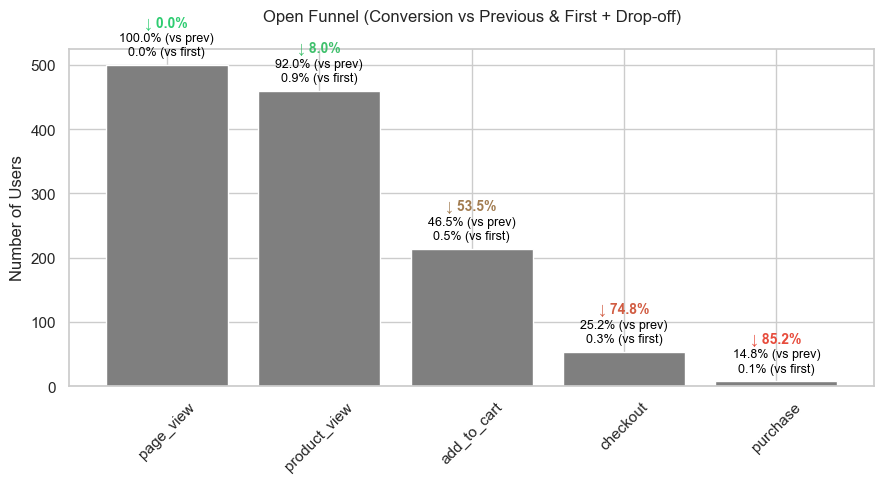

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Calculate drop-off %
funnel_counts['drop_percent'] = (1 - funnel_counts['users'] / funnel_counts['users'].shift(1)) * 100
funnel_counts.loc[0, 'drop_percent'] = 0

# X positions
x = np.arange(len(funnel_counts['step']))

# Gray bar
bar_color = '#7f7f7f'

# Green-to-red gradient
cmap = mcolors.LinearSegmentedColormap.from_list("drop_scale", ["#2ECC71", "#E74C3C"])
norm = plt.Normalize(funnel_counts['drop_percent'].min(), funnel_counts['drop_percent'].max())

plt.figure(figsize=(9,5))

# Bars
plt.bar(x, funnel_counts['users'], color=bar_color)

# Labels
for xpos, users, step_conv, total_conv, drop in zip(
    x,
    funnel_counts['users'],
    funnel_counts['step_conversion'],
    funnel_counts['conversion_rate'],
    funnel_counts['drop_percent']
):
    # Original labels (above the bar)
    plt.text(
        xpos,
        users + max(funnel_counts['users'])*0.02,
        f"{step_conv:.1f}% (vs prev)\n{total_conv:.1f}% (vs first)",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )
    
    # Drop-off label (above the bar)
    drop_color = cmap(norm(drop))
    plt.text(
        xpos,
        users + max(funnel_counts['users'])*0.11,
        f"↓ {drop:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=drop_color
    )

# Style
plt.xticks(x, funnel_counts['step'], rotation=45)
plt.ylabel("Number of Users")
plt.title("Open Funnel (Conversion vs Previous & First + Drop-off)", pad=20)
plt.tight_layout()
plt.show()

### Insights:

- High engagement at the top of the funnel (92% reach product view)

Major drop-off occurs at:

- Add to Cart → Checkout (−74.8%)

- Checkout → Purchase (−85.2%)

⚠️ However, this funnel does not enforce user sequence, so it may overestimate progression.

## Sequential Funnel
### Sequential Funnel
This funnel tracks user progression through key steps of the purchase journey. 
Only users who complete each step are counted in the subsequent step, 
ensuring a true sequential funnel rather than an open funnel.


In [ ]:
import pandas as pd

# Define the funnel steps
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout', 'purchase']

# Sort events by user and time
df_sorted = df_clean.sort_values(['user_id', 'timestamp'])

# Create a DataFrame to store the status of each user
users_state = pd.DataFrame({'user_id': df_sorted['user_id'].unique()})
users_state['last_time'] = pd.NaT  # Last timestamp of the completed step

seq_funnel = []

for i, step in enumerate(funnel_steps):
    # Filter events of the current step
    step_events = df_sorted[df_sorted['event'] == step][['user_id', 'timestamp']]

    # Merge with current status
    merged = users_state.merge(step_events, on='user_id', how='left')

    if i == 0:
        # First step: any valid timestamp
        valid_users = merged[merged['timestamp'].notna()].copy()
    else:
        # Next steps: timestamp must be later than the last completed step
        valid_users = merged[
            (merged['timestamp'].notna()) &
            (merged['timestamp'] > merged['last_time'])
        ].copy()

    # Save results
    seq_funnel.append({
        'step': step,
        'users': valid_users['user_id'].nunique()
    })

    # Update status for the next step
    users_state = valid_users[['user_id', 'timestamp']].rename(columns={'timestamp': 'last_time'})

# Convert to DataFrame
seq_funnel = pd.DataFrame(seq_funnel)

# Calculate conversions and drop-offs
seq_funnel['step_conversion'] = (seq_funnel['users'] / seq_funnel['users'].shift(1) * 100).round(1)
seq_funnel.loc[0, 'step_conversion'] = 100

seq_funnel['total_conversion'] = (seq_funnel['users'] / seq_funnel['users'].iloc[0] * 100).round(1)
seq_funnel['drop_percent'] = (100 - seq_funnel['step_conversion']).round(1)

seq_funnel

,step,users,step_conversion,total_conversion,drop_percent
0,page_view,500,100.0,100.0,0.0
1,product_view,460,92.0,92.0,8.0
2,add_to_cart,214,46.5,42.8,53.5
3,checkout,54,25.2,10.8,74.8
4,purchase,8,14.8,1.6,85.2


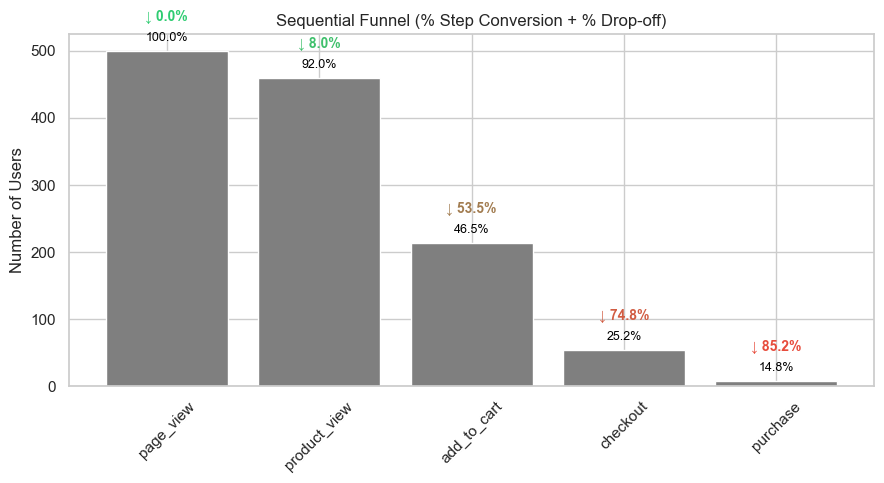

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Use the actual sequential funnel
funnel_data = seq_funnel.copy()

# Axes
x = np.arange(len(funnel_data['step']))

# Gray bars
bar_color = '#7f7f7f'

# Green → red gradient according to drop_percent
cmap = mcolors.LinearSegmentedColormap.from_list("drop_scale", ["#2ECC71", "#E74C3C"])
norm = plt.Normalize(funnel_data['drop_percent'].min(), funnel_data['drop_percent'].max())

plt.figure(figsize=(9,5))

# Bars
plt.bar(x, funnel_data['users'], color=bar_color)

# Labels
for xpos, users, step_conv, drop in zip(
    x,
    funnel_data['users'],
    funnel_data['step_conversion'],
    funnel_data['drop_percent']
):
    # Step conversion %
    plt.text(xpos, users + max(funnel_data['users'])*0.02,
             f"{step_conv:.1f}%",
             ha='center', va='bottom', fontsize=9, color='black')
    
    # Drop-off % (above the bar)
    drop_color = cmap(norm(drop))
    plt.text(xpos, users + max(funnel_data['users'])*0.08,
             f"↓ {drop:.1f}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=drop_color)

# Style
plt.xticks(x, funnel_data['step'], rotation=45)
plt.ylabel("Number of Users")
plt.title("Sequential Funnel (% Step Conversion + % Drop-off)")
plt.tight_layout()
plt.show()

### Insights:
- Strong initial engagement, but significant drop-offs occur in the lower funnel.
- Critical drop-off points:
  - Add to Cart → Checkout
  - Checkout → Purchase
- Only 1.6% of users complete a purchase.
- This sequential funnel uses timestamps, so these drop-offs reflect **actual user progression and abandonment**.

### Conclusion

- The funnel shows strong top-level engagement but weak conversion performance
- The main bottlenecks are located in the cart and checkout stages
- There is a significant gap between user intent and completed purchases

The comparison between open and sequential funnels highlights the importance of analyzing both behavior and true user progression.

### Opportunities for Improvement

#### 1. Improve Cart Experience
- Reduce friction and distractions
- Highlight checkout CTA

#### 2. Optimize Checkout Flow
- Simplify steps
- Enable guest checkout

#### 3. Reduce Payment Friction
- Add multiple payment methods
- Increase transparency and trust

#### 4. Run A/B Tests
- Test checkout simplification
- Test cart UI improvements

## User Distribution by Country & Device

In [67]:
# Count users by country
users_by_country = df_clean.groupby('country')['user_id'].nunique().sort_values(ascending=False)

print("Number of unique users per country:")
print(users_by_country)

Number of unique users per country:
country
it         209
es         112
de          87
fr          67
unknown     25
Name: user_id, dtype: int64


In [68]:
# Count users by device
users_by_device = df_clean.groupby('device')['user_id'].nunique().sort_values(ascending=False)

print("\nNumber of unique users per device:")
print(users_by_device)


Number of unique users per device:
device
mobile     276
desktop    179
unknown     45
Name: user_id, dtype: int64


In [69]:
import pandas as pd

# --- 1️⃣ Pivot table: number of users by country and device ---
users_country_device = pd.pivot_table(
    df_clean,
    index='country',
    columns='device',
    values='user_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# --- 2️⃣ Calculate total users per country ---
users_country_device["Total"] = users_country_device.sum(axis=1)

# --- 3️⃣ Calculate percentage of each device within each country ---
users_country_device_pct = users_country_device.drop(columns="Total").div(
    users_country_device["Total"], axis=0
) * 100

# --- 4️⃣ Create combined table: count + percentage ---
table = users_country_device.drop(columns="Total").copy().astype(str)

for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        count = users_country_device.iloc[i, j]
        pct = users_country_device_pct.iloc[i, j]
        table.iloc[i, j] = f"{count} ({pct:.1f}%)"

# --- 5️⃣ Add total column ---
table["Total"] = users_country_device["Total"]

# --- 6️⃣ Sort countries by total users in descending order ---
table = table.sort_values(by="Total", ascending=False)

# --- 7️⃣ Display table ---
print("\nUsers by Country and Device (with totals and %):")
table


Users by Country and Device (with totals and %):


device,desktop,mobile,unknown,Total
country,,,,
it,80 (38.3%),114 (54.5%),15 (7.2%),209
es,40 (35.7%),63 (56.2%),9 (8.0%),112
de,23 (26.4%),53 (60.9%),11 (12.6%),87
fr,31 (46.3%),30 (44.8%),6 (9.0%),67
unknown,5 (20.0%),16 (64.0%),4 (16.0%),25


Stacked bars

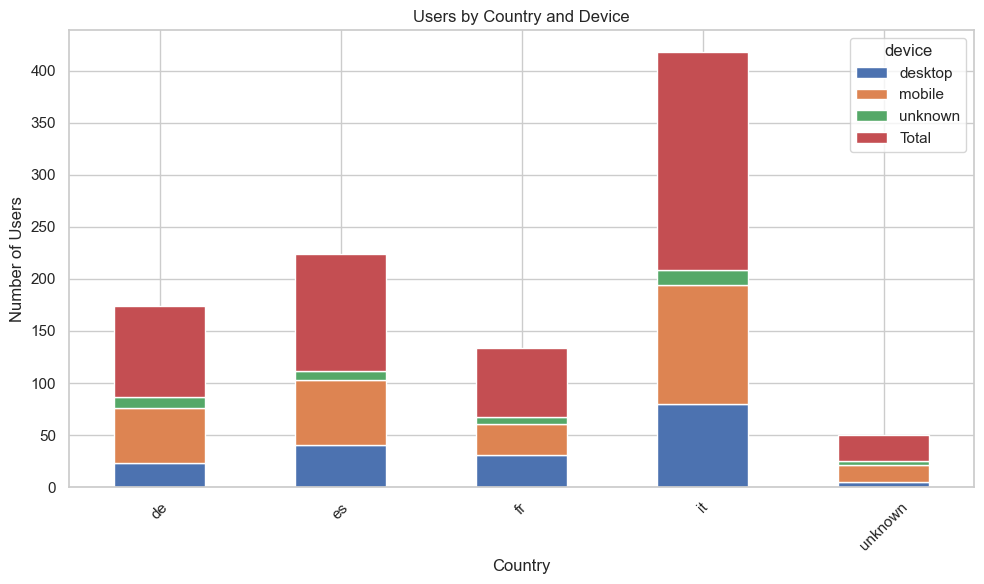

In [70]:
users_country_device.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Users by Country and Device")
plt.ylabel("Number of Users")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Heatmap

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot table: number of unique users by country and device
users_country_device = pd.pivot_table(
    df_clean,
    index='country',
    columns='device',
    values='user_id',
    aggfunc=lambda x: x.nunique(),  # count unique users
    fill_value=0
)

# Total users per country (users should be unique across devices)
# This ensures total per country does not double-count
users_country_device["Total"] = df_clean.groupby("country")["user_id"].nunique()

In [72]:
# Percentage of each device per country
users_country_device_pct = users_country_device.drop(columns="Total").div(
    users_country_device["Total"], axis=0
) * 100

In [73]:
# Create annotations for heatmap

# Combine count + percentage for each cell
annotations = users_country_device.drop(columns="Total").copy().astype(str)

for i in range(annotations.shape[0]):
    for j in range(annotations.shape[1]):
        count = users_country_device.iloc[i, j]
        pct = users_country_device_pct.iloc[i, j]
        annotations.iloc[i, j] = f"{count}\n({pct:.1f}%)"

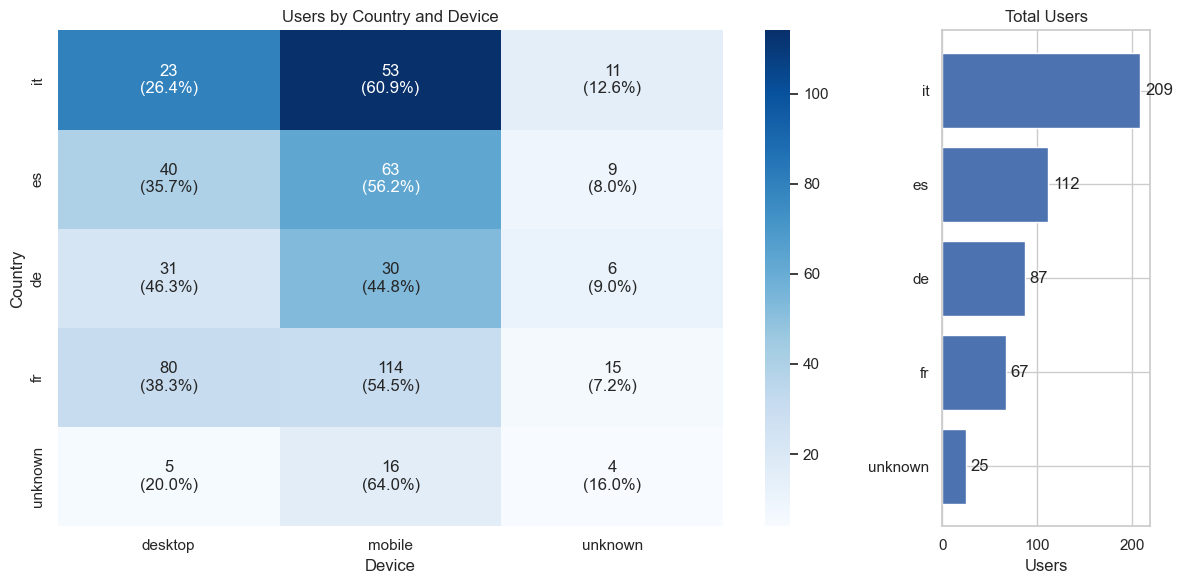

In [74]:
# Create heatmap

# Sort countries by total users
users_country_device = users_country_device.sort_values(by="Total", ascending=False)

heatmap_data = users_country_device.drop(columns="Total")
totals = users_country_device["Total"]

# Figure with two subplots
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12,6),
    gridspec_kw={'width_ratios':[4,1]}
)

# Heatmap
sns.heatmap(
    heatmap_data,
    annot=annotations,
    fmt="",
    cmap="Blues",
    ax=ax1
)
ax1.set_title("Users by Country and Device")
ax1.set_xlabel("Device")
ax1.set_ylabel("Country")

# Side bar with total users per country
bars = ax2.barh(totals.index, totals.values)

# Add total labels at the end of each bar
for i, value in enumerate(totals.values):
    ax2.text(value + 5, i, str(value), va='center')  # +5 to offset slightly

ax2.set_title("Total Users")
ax2.set_xlabel("Users")
ax2.set_ylabel("")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### Insights

- At a global level, users from four representative European countries (Italy, Spain, Germany, and France) primarily choose to make purchases via mobile devices.

- French users appear to use mobile and desktop in a more balanced way.

## Segmented Funnel Analysis: Country × Device

This section analyzes user progression and conversion rates across countries and devices, highlighting regions and devices with the highest drop-off or lowest conversion.

In [75]:
# Total users per country × device
total_users = pd.pivot_table(
    df_clean[df_clean['device'] != 'unknown'],  # exclude unknown devices
    index='country',
    columns='device',
    values='user_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# Purchased users per country × device
purchased_users = pd.pivot_table(
    df_clean[(df_clean['device'] != 'unknown') & (df_clean['event']=='purchase')],
    index='country',
    columns='device',
    values='user_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

In [76]:
# Calculate conversion rate (%) by segment
conversion_rate = (purchased_users / total_users * 100).fillna(0)

In [77]:
# Combine n users + conversion rate in a table

# Initialize table
table_segment = total_users.copy().astype(str)

# Fill each cell with "n users (conversion %)"
for i in range(table_segment.shape[0]):
    for j in range(table_segment.shape[1]):
        count = total_users.iloc[i, j]
        conv = conversion_rate.iloc[i, j]
        table_segment.iloc[i, j] = f"{count} ({conv:.1f}%)"

# Add total users per country
table_segment['Total Users'] = total_users.sum(axis=1)

# Sort by total users descending
table_segment = table_segment.sort_values(by='Total Users', ascending=False)

# Show table
print("\nUsers and Conversion Rate by Country and Device:")
table_segment


Users and Conversion Rate by Country and Device:


device,desktop,mobile,Total Users
country,,,
it,80 (3.8%),114 (0.0%),194
es,40 (2.5%),63 (3.2%),103
de,23 (0.0%),53 (0.0%),76
fr,31 (0.0%),30 (3.3%),61
unknown,5 (0.0%),16 (6.2%),21


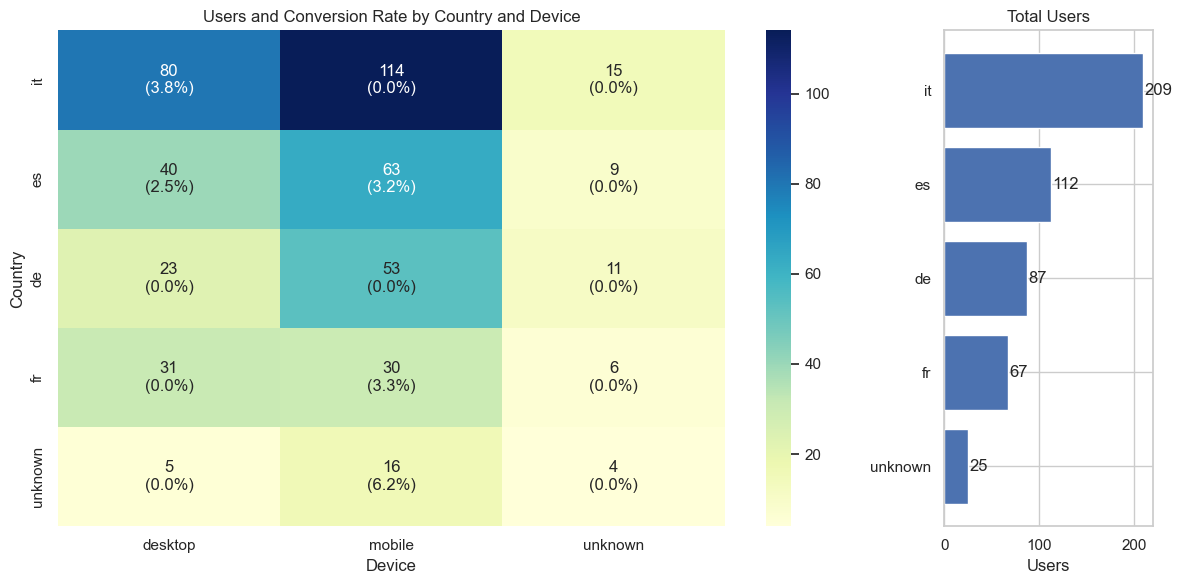

In [78]:
# Heatmap

# --- Pivot tables ---
total_users = pd.pivot_table(
    df_clean,
    index='country',
    columns='device',
    values='user_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

purchased_users = pd.pivot_table(
    df_clean[df_clean['event']=='purchase'],
    index='country',
    columns='device',
    values='user_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# --- Conversion rate (%) ---
conversion_rate = (purchased_users / total_users * 100).fillna(0)

# --- Create annotations (n users + conversion %) ---
annotations = total_users.copy().astype(str)

for i in range(annotations.shape[0]):
    for j in range(annotations.shape[1]):
        count = total_users.iloc[i, j]
        conv = conversion_rate.iloc[i, j]
        annotations.iloc[i, j] = f"{count}\n({conv:.1f}%)"

# --- Add total users per country ---
total_users['Total Users'] = total_users.sum(axis=1)

# --- Sort countries by total users ---
total_users = total_users.sort_values(by='Total Users', ascending=False)

# Reorder annotations to match sorted countries
annotations = annotations.loc[total_users.index]

# --- Plot heatmap + side bar ---
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12,6),
    gridspec_kw={'width_ratios':[4,1]}
)

# Heatmap
sns.heatmap(
    total_users.drop(columns='Total Users'),
    annot=annotations,
    fmt="",
    cmap="YlGnBu",
    ax=ax1
)

ax1.set_title("Users and Conversion Rate by Country and Device")
ax1.set_xlabel("Device")
ax1.set_ylabel("Country")

# Side bar: total users per country
bars = ax2.barh(total_users.index, total_users['Total Users'])

# Add labels to bars
for i, value in enumerate(total_users['Total Users']):
    ax2.text(value + 2, i, str(value), va='center')

ax2.set_title("Total Users")
ax2.set_xlabel("Users")
ax2.set_ylabel("")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### Insights:

- Italy (IT) shows a significant disparity between devices: desktop users convert at 3.8%, while mobile users have 0% conversion despite being the larger group. This indicates a major mobile UX or checkout issue that should be prioritized.
- Spain (ES) shows relatively better mobile conversion (3.2%) compared to desktop (2.5%).
- Germany (DE) has moderate user volume but very low conversion on both devices, indicating potential friction in the funnel.
- France (FR) shows a minor mobile conversion advantage (3.3%) over desktop (0.0%).
- Users with unknown country show the highest mobile conversion (6.2%), which could indicate tracking or segmentation issues.

### Key takeaway:

- Conversion rates vary significantly across **countries and devices**.  
- **Mobile performance is inconsistent** and often the weak point, especially in Italy and Germany.  
- Prioritizing **mobile UX improvements, checkout flow optimization, and country-specific tests** is likely to have the greatest impact on overall conversions.

👉 This indicates conversion inefficiencies.

### Data Limitations

- Some countries have very low user counts (e.g., Unknown = 21 users, France = 61 users), which makes percentage-based conversion rates **less reliable**.
- Low volumes can exaggerate apparent differences between devices. For example, a single converted user can dramatically change the conversion rate in small samples.
- These results should be interpreted with caution and are better used for **trend identification** rather than absolute conclusions.
- For countries with small sample sizes, further data collection or aggregation may be necessary before implementing major optimization changes.


## User Segmentation: New vs Returning Users

To further refine the analysis, users were segmented into new and returning groups.

This distinction is important, as these two segments typically exhibit different behaviors in terms of engagement and conversion.

By analyzing them separately, we can better understand where friction occurs and identify more targeted optimization opportunities.

In [ ]:
import pandas as pd

# Define funnel steps
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout', 'purchase']

# List of user types
user_types = df_clean['user_type'].unique()

# Dictionaries to store results
step_conv_dict = {}
drop_dict = {}
counts_dict = {}

for utype in user_types:
    # Filter by user type
    df_utype = df_clean[df_clean['user_type'] == utype].sort_values(['user_id','timestamp'])
    
    # User status
    users_state = pd.DataFrame({'user_id': df_utype['user_id'].unique()})
    users_state['last_time'] = pd.NaT
    
    users_per_step = []
    
    for i, step in enumerate(funnel_steps):
        step_events = df_utype[df_utype['event'] == step][['user_id','timestamp']]
        merged = users_state.merge(step_events, on='user_id', how='left')
        
        if i == 0:
            valid_users = merged[merged['timestamp'].notna()].copy()
        else:
            valid_users = merged[(merged['timestamp'].notna()) & (merged['timestamp'] > merged['last_time'])].copy()
        
        # Save the number of users who complete this step
        users_per_step.append(valid_users['user_id'].nunique())
        
        # Update status for the next step
        users_state = valid_users[['user_id','timestamp']].rename(columns={'timestamp':'last_time'})
    
    # Create temporary DataFrame
    df_funnel = pd.DataFrame({'step': funnel_steps, 'users': users_per_step})
    
    # Calculate step conversion and drop-off
    df_funnel['step_conversion'] = (df_funnel['users'] / df_funnel['users'].shift(1) * 100).round(1)
    df_funnel.loc[0,'step_conversion'] = 100
    df_funnel['drop_percent'] = (100 - df_funnel['step_conversion']).round(1)
    
    # Save in dictionaries
    counts_dict[utype] = df_funnel.set_index('step')['users']
    step_conv_dict[utype] = df_funnel.set_index('step')['step_conversion']
    drop_dict[utype] = df_funnel.set_index('step')['drop_percent']

# Convert dictionaries to DataFrames
funnel_user_type_counts = pd.DataFrame(counts_dict)
funnel_user_type_step_conv = pd.DataFrame(step_conv_dict)
funnel_user_type_drop = pd.DataFrame(drop_dict)

In [ ]:
#Number of users per step (sequential, by user type)
print("=== Users per step by User Type ===")
display(funnel_user_type_counts)

# Step conversion (%) per step
print("=== Step Conversion (%) by User Type ===")
display(funnel_user_type_step_conv)

# Drop-off (%) per step
print("=== Drop-off (%) by User Type ===")
display(funnel_user_type_drop)

# Optional: combine them into a single summary DataFrame
funnel_user_type_summary = pd.concat(
    [
        funnel_user_type_counts.add_suffix('_users'),
        funnel_user_type_step_conv.add_suffix('_step_conv%'),
        funnel_user_type_drop.add_suffix('_drop%')
    ],
    axis=1
)

print("=== Full Funnel Summary by User Type ===")
display(funnel_user_type_summary)

=== Users per step by User Type ===


,returning,new
step,,
page_view,136,364
product_view,127,333
add_to_cart,59,155
checkout,17,37
purchase,3,5


=== Step Conversion (%) by User Type ===


,returning,new
step,,
page_view,100.0,100.0
product_view,93.4,91.5
add_to_cart,46.5,46.5
checkout,28.8,23.9
purchase,17.6,13.5


=== Drop-off (%) by User Type ===


,returning,new
step,,
page_view,0.0,0.0
product_view,6.6,8.5
add_to_cart,53.5,53.5
checkout,71.2,76.1
purchase,82.4,86.5


=== Full Funnel Summary by User Type ===


,returning_users,new_users,returning_step_conv%,new_step_conv%,returning_drop%,new_drop%
step,,,,,,
page_view,136,364,100.0,100.0,0.0,0.0
product_view,127,333,93.4,91.5,6.6,8.5
add_to_cart,59,155,46.5,46.5,53.5,53.5
checkout,17,37,28.8,23.9,71.2,76.1
purchase,3,5,17.6,13.5,82.4,86.5


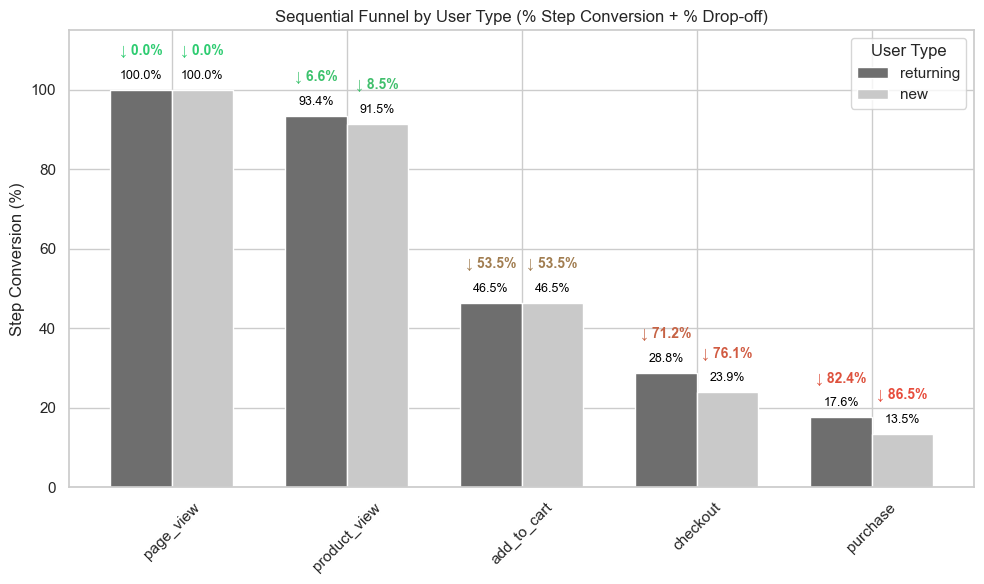

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Data for the chart
funnel_steps = funnel_user_type_step_conv.index
user_types = funnel_user_type_step_conv.columns
x = np.arange(len(funnel_steps))
width = 0.35  # ancho de las barras

# Bar colors by user type
bar_colors = ['#6e6e6e', '#c9c9c9']  # New, Returning

# Green → red gradient for drop-off
cmap = mcolors.LinearSegmentedColormap.from_list("drop_scale", ["#2ECC71", "#E74C3C"])
norm = plt.Normalize(funnel_user_type_drop.min().min(), funnel_user_type_drop.max().max())

plt.figure(figsize=(10,6))

for i, user_type in enumerate(user_types):
    bar_heights = funnel_user_type_step_conv[user_type].values
    
    # Draw bars
    plt.bar(x + i*width, bar_heights, width=width, label=user_type, color=bar_colors[i])
    
    # Add Step Conversion and Drop-off labels
    for xpos, height, step in zip(x + i*width, bar_heights, funnel_steps):
        # Step conversion %
        plt.text(xpos, height + 2, f"{height:.1f}%", ha='center', va='bottom', fontsize=9, color='black')
        
        # Drop-off %
        drop = funnel_user_type_drop.loc[step, user_type]
        drop_color = cmap(norm(drop))
        plt.text(xpos, height + 8, f"↓ {drop:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold', color=drop_color)

# Style
plt.xticks(x + width/2, funnel_steps, rotation=45)
plt.ylabel("Step Conversion (%)")
plt.ylim(0, 115)
plt.title("Sequential Funnel by User Type (% Step Conversion + % Drop-off)")
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

### Insights:
- Early funnel engagement is strong for both user types, indicating that marketing efforts effectively drive users to the site.
- The majority of drop-off occurs in the lower funnel, specifically between **Add to Cart → Checkout → Purchase**, for both groups.
- Returning users convert slightly better, which is expected as they are familiar with the platform and purchase flow.
- There is a clear opportunity to optimize the checkout process, particularly for **New users**, to reduce abandonment.
- These drop-off percentages reflect **actual sequential abandonment**, as the funnel enforces chronological order of events.

## Funnel Performance by Country, Device & User Type
This section explores how funnel conversion varies across countries, devices, and user types. The goal is to identify behavioral differences and detect where the largest performance gaps and optimization opportunities exist.

In [ ]:
import pandas as pd
import numpy as np

# --- Funnel steps ---
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout', 'purchase']

# --- List for results---
funnel_segment = []

# --- Unique segment combinations ---
combinations = df_clean[['country', 'device', 'user_type']].drop_duplicates()

for _, row in combinations.iterrows():
    country = row['country']
    device = row['device']
    user_type = row['user_type']
    
    # Filter data for the segment
    df_seg = df_clean[
        (df_clean['country'] == country) &
        (df_clean['device'] == device) &
        (df_clean['user_type'] == user_type)
    ].sort_values(['user_id', 'timestamp'])
    
    # All unique users
    users_so_far = df_seg['user_id'].unique()
    
    for step in funnel_steps:
        # Users who completed the step sequentially
        users_this_step = df_seg[
            (df_seg['user_id'].isin(users_so_far)) &
            (df_seg['event'] == step)
        ]['user_id'].unique()
        
        funnel_segment.append({
            'country': country,
            'device': device,
            'user_type': user_type,
            'step': step,
            'users': len(users_this_step)
        })
        
        # Only users who completed this step advance
        users_so_far = users_this_step

# Convert to DataFrame
funnel_segment = pd.DataFrame(funnel_segment)

# --- Ensure correct order of steps ---
step_order = {step: i for i, step in enumerate(funnel_steps)}
funnel_segment['step_order'] = funnel_segment['step'].map(step_order)

funnel_segment = funnel_segment.sort_values(
    ['country','device','user_type','step_order']
).reset_index(drop=True)

# --- Calculate step conversion robustly ---
step_conv_list = []

for (country, device, user_type), group in funnel_segment.groupby(['country','device','user_type']):
    prev_users = None
    for idx, row in group.iterrows():
        if prev_users is None:
            step_conv = 100.0
        elif prev_users == 0:
            step_conv = 0.0
        else:
            step_conv = (row['users'] / prev_users) * 100
        step_conv_list.append(step_conv)
        prev_users = row['users']

funnel_segment['step_conversion'] = step_conv_list
funnel_segment['drop_percent'] = 100 - funnel_segment['step_conversion']

# --- Total conversion vs first step ---
funnel_segment['total_conversion'] = funnel_segment.groupby(
    ['country','device','user_type']
)['users'].transform(lambda x: (x / x.iloc[0]) * 100)

# --- Round ---
funnel_segment[['step_conversion','total_conversion','drop_percent']] = \
    funnel_segment[['step_conversion','total_conversion','drop_percent']].round(1)

# --- Clean auxiliary column ---
funnel_segment = funnel_segment.drop(columns=['step_order'])

# --- View the first 20 results ---
funnel_segment

,country,device,user_type,step,users,step_conversion,drop_percent,total_conversion
0,de,desktop,new,page_view,15,100.0,0.0,100.0
1,de,desktop,new,product_view,14,93.3,6.7,93.3
2,de,desktop,new,add_to_cart,8,57.1,42.9,53.3
3,de,desktop,new,checkout,3,37.5,62.5,20.0
4,de,desktop,new,purchase,0,0.0,100.0,0.0
...,...,...,...,...,...,...,...,...
135,unknown,unknown,new,page_view,4,100.0,0.0,100.0
136,unknown,unknown,new,product_view,3,75.0,25.0,75.0
137,unknown,unknown,new,add_to_cart,0,0.0,100.0,0.0
138,unknown,unknown,new,checkout,0,0.0,100.0,0.0


In [ ]:
# Display the entire DataFrame in the notebook
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(funnel_segment)

     country   device  user_type          step  users  step_conversion  \
0         de  desktop        new     page_view     15            100.0   
1         de  desktop        new  product_view     14             93.3   
2         de  desktop        new   add_to_cart      8             57.1   
3         de  desktop        new      checkout      3             37.5   
4         de  desktop        new      purchase      0              0.0   
5         de  desktop  returning     page_view      8            100.0   
6         de  desktop  returning  product_view      8            100.0   
7         de  desktop  returning   add_to_cart      5             62.5   
8         de  desktop  returning      checkout      1             20.0   
9         de  desktop  returning      purchase      0              0.0   
10        de   mobile        new     page_view     38            100.0   
11        de   mobile        new  product_view     37             97.4   
12        de   mobile        new   add

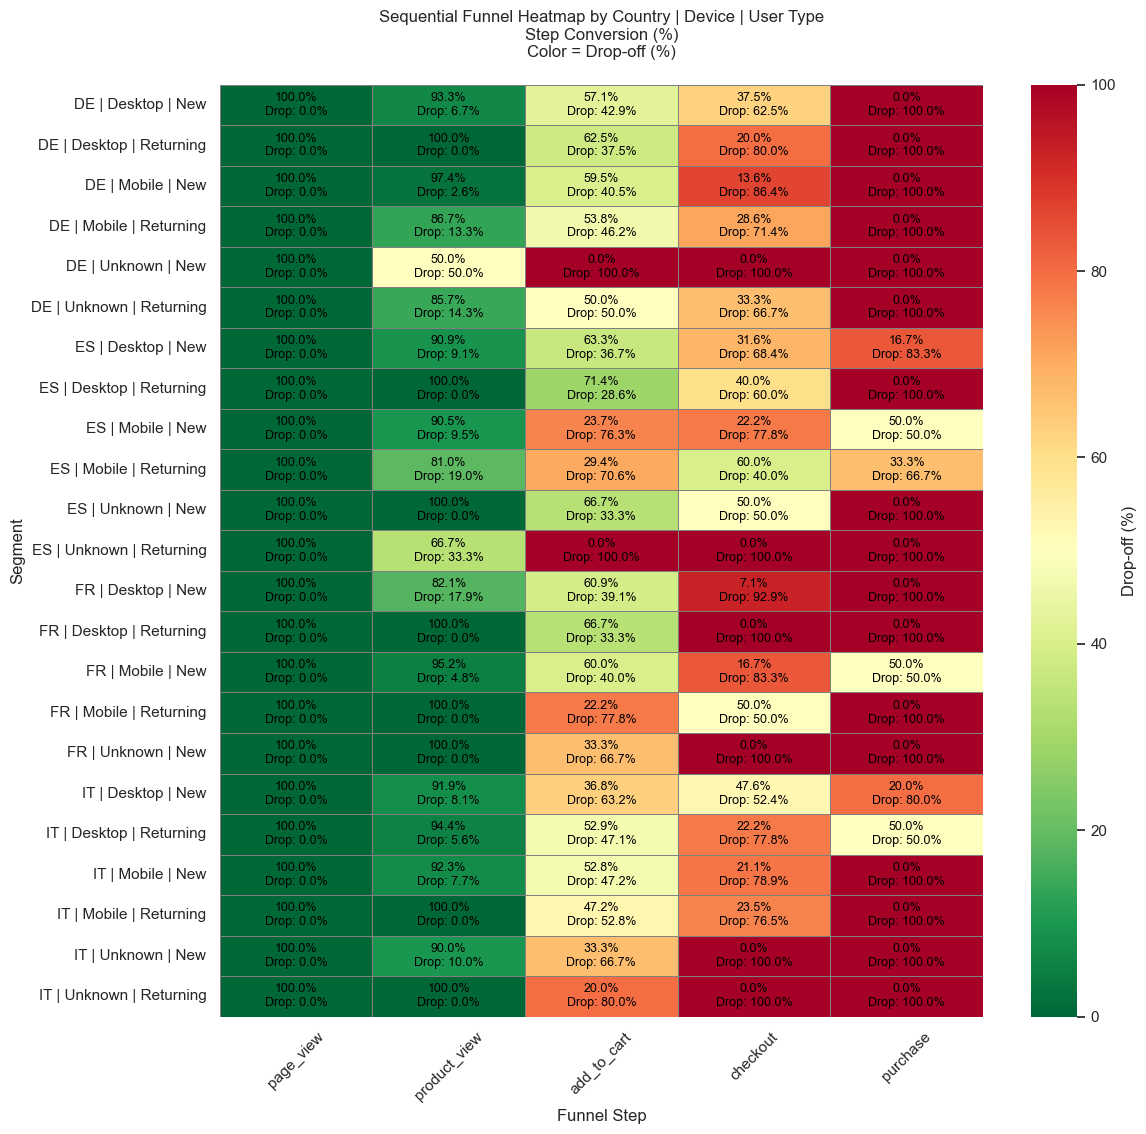

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Filter only known countries ---
df_heat = funnel_segment[funnel_segment['country'] != 'unknown'].copy()

# --- Create segment column by combining country, device, and user type ---
df_heat['segment'] = df_heat['country'].str.upper() + ' | ' + \
                     df_heat['device'].str.capitalize() + ' | ' + \
                     df_heat['user_type'].str.capitalize()

# --- Pivot table: rows = segment, columns = step, values = step_conversion ---
heatmap_step = df_heat.pivot(index='segment', columns='step', values='step_conversion')
heatmap_step = heatmap_step[funnel_steps]

# --- Pivot table for drop-off ---
heatmap_drop = df_heat.pivot(index='segment', columns='step', values='drop_percent')
heatmap_drop = heatmap_drop[funnel_steps]

# --- Create heatmap using drop-off as color---
plt.figure(figsize=(12, max(6, 0.5*len(heatmap_step))))

ax = sns.heatmap(
    heatmap_drop,
    annot=False, cmap="RdYlGn_r", cbar_kws={'label': 'Drop-off (%)'},
    linewidths=0.5, linecolor='gray'
)

# --- Annotate values inside each cell ---
for y in range(heatmap_step.shape[0]):
    for x in range(heatmap_step.shape[1]):
        step_conv = heatmap_step.iloc[y, x]
        drop = heatmap_drop.iloc[y, x]
        # Step conversion in black, Drop-off in smaller gray
        ax.text(
            x + 0.5, y + 0.5,
            f"{step_conv:.1f}%\nDrop: {drop:.1f}%",
            ha='center', va='center', fontsize=9, color='black'
        )

plt.title("Sequential Funnel Heatmap by Country | Device | User Type\nStep Conversion (%)\nColor = Drop-off (%)", pad=20)
plt.ylabel("Segment")
plt.xlabel("Funnel Step")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights & Trends

#### 🚨**Core Issue**
- Conversion collapses at checkout → purchase
- Near 0% purchase rate across most markets
- Indicates payment / final step failure (not demand issue)
#### 📉 **Key Bottlenecks**
- Checkout → Purchase: critical drop (primary issue)
- Add to Cart → Checkout: strong friction (especially mobile)
- Mobile underperforms desktop at every stage
#### 🌍 **Market Highlights**
- 🇩🇪 Germany: 0 purchases → critical failure in checkout/payment  
- 🇪🇸 Spain: best-performing market → some successful conversions (benchmark)  
- 🇫🇷 France: strong interest, weak checkout transition (except mobile new users)  
- 🇮🇹 Italy: high traffic, consistent drop-offs in checkout and purchase  
#### 👥 **User Insights**
- **New users**: strong interest, drop before checkout  
- **Returning users**: slightly better mid-funnel, but no significant uplift in purchase  
- **Intent is present** (`add_to_cart` strong) → execution problem in final steps 
#### 🔥 **Key Takeaways**
- Funnel issue is bottom-of-funnel, not acquisition
- Mobile UX is the biggest performance gap
- Checkout experience is the main blocker to revenue

### 🎯 Recommended Actions (Priority)
1. **Audit checkout flow**  
   - Payment methods, errors, load time, hidden costs  

2. **Optimize mobile checkout**  
   - Fewer steps, autofill, express payments  

3. **Improve cart → checkout transition**  
   - Guest checkout, reduce friction  

4. **Deep dive Germany**  
   - Payment localization & trust signals  

## 🧾 Conclusion

The funnel analysis reveals that **user intent is strong across all markets**, with consistent progression through the early stages (`page_view → product_view → add_to_cart`).  

However, there is a **systematic breakdown in the final stages of the funnel**, particularly from **checkout to purchase**, where conversion drops sharply across nearly all segments.  

This pattern indicates that the primary issue is not acquisition or engagement, but rather **friction in the checkout experience**, especially on mobile devices.  

While some markets such as Spain show relatively better performance, the overall trend is consistent: **users are willing to buy but fail to complete the transaction**.  

➡️ **Final takeaway:** Improving the checkout and payment experience—especially on mobile—represents the largest opportunity to increase overall conversion and revenue.